Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=127983305014448 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=124,647,939 params_trainable=124,647,939


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,1.089900,0.354069,0.906667,0.906042,0.907326,0.906667,0.056436,16.930756
2,0.221000,0.179580,0.936667,0.937077,0.941951,0.936667,0.031693,9.507888
3,0.140600,0.137553,0.953333,0.953139,0.953938,0.953333,0.023026,6.907904
4,0.078000,0.172497,0.953333,0.953290,0.953636,0.953333,0.026391,7.917270
5,0.062900,0.193833,0.950000,0.949722,0.951052,0.950000,0.026585,7.975576
6,0.051800,0.196615,0.953333,0.953006,0.954289,0.953333,0.025593,7.678010
7,0.046400,0.175625,0.960000,0.959829,0.960545,0.960000,0.022238,6.671378
8,0.031300,0.178962,0.963333,0.963204,0.963698,0.963333,0.022014,6.604301
9,0.025600,0.193029,0.970000,0.969945,0.970182,0.970000,0.019935,5.980424
10,0.020100,0.194927,0.966667,0.966576,0.966909,0.966667,0.020794,6.238059


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=15.24s tok/s=0.0 ex/s=0.00 peak_mem=2.44GiB lr=9.68e-06
[EVALUATION_PERFORMANCE] tokens=81920 time=0.15s tok/s=531367.5 ex/s=4151.31
[EVALUATION_PERFORMANCE] accuracy=0.9067 cost=$0.01 accuracy_per_$=102.60
[OPTIMIZER] epoch_start=1.0 global_step=75 wrapped=AcceleratedOptimizer base=AdamW lr=9.684361549497849e-06 id=127983305014448 hyperparams={'lr': 9.684361549497849e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 9.684361549497849e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[9.684361549497849e-06]
[PARAMS]   p

[EVALUATION_PERFORMANCE] tokens=81920 time=0.32s tok/s=253433.5 ex/s=1979.95
[EVALUATION_PERFORMANCE] accuracy=0.9600 cost=$0.15 accuracy_per_$=6.40

### ROBERTA-BASE EVALUATION METRICS ###
{'epoch': 10.0,
 'eval_accuracy': 0.96,
 'eval_f1_macro': 0.9600160004000099,
 'eval_loss': 0.24156999588012695,
 'eval_mse': 0.026303694848529565,
 'eval_precision_macro': 0.96006400640064,
 'eval_recall_macro': 0.96,
 'eval_runtime': 0.3838,
 'eval_samples_per_second': 781.632,
 'eval_sse': 7.89110845455887,
 'eval_steps_per_second': 13.027}


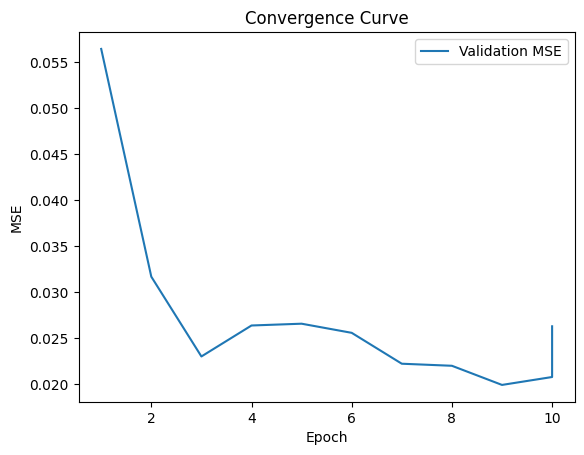

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    roberta_context = context.setup_pipeline(Roberta, require_translation = False)
    roberta_trainer = sentiment.train(roberta_context)

